[54.2733302  50.49068725 52.65892423 50.79232005 53.1640095 ]


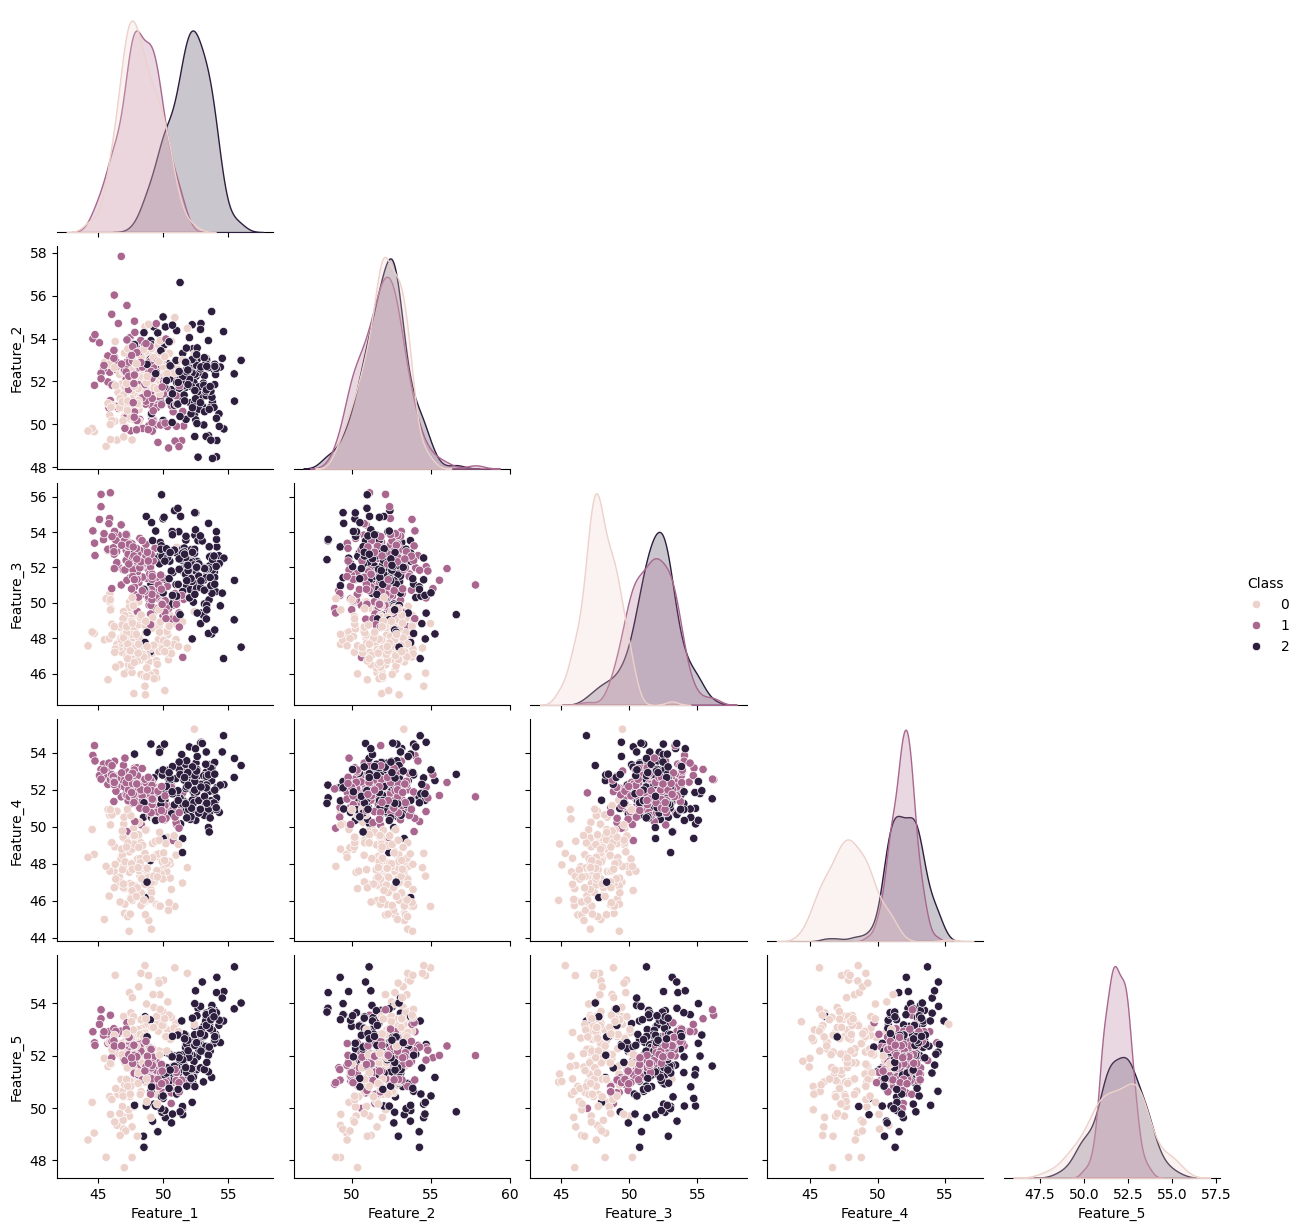

In [63]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_classification, make_gaussian_quantiles
import seaborn as sns
import pandas as pd

n_classes = 3
n_features = 5
X1, Y1 = make_classification(n_features=n_features, n_redundant=0, n_informative=5, n_classes=n_classes, n_clusters_per_class=1, shift=50, n_samples=500, class_sep=2.)
# X1, Y1 = make_blobs(n_features=5, centers=n_classes, n_samples=500, center_box=(50, 60))
# X1, Y1 = make_gaussian_quantiles(n_samples=500, n_features=5, n_classes=n_classes, mean=(50, 60, 55, 45, 60), cov=5)
# dat1 = pd.DataFrame(X1, columns = ['0', '1', '2', '3', '4'])
dat1 = pd.DataFrame(X1, columns = [[str(i) for i in range(n_features)]])
res1 = pd.DataFrame(Y1, columns = ['type'])
dat1_full = dat1.join(res1)
# plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
print(X1[0])
# print(Y1)
# for i in dat1_full.columns:
#     for j in dat1_full.columns:
#         if ( i != 'type' and j != 'type' and i < j):
#             g = sns.FacetGrid(dat1_full, hue = 'type',  legend_out=True)
#             g.map(sns.regplot, i, j, fit_reg=True, x_jitter=.1)

df = pd.DataFrame(X1, columns=[f'Feature_{i+1}' for i in range(X1.shape[1])])
df['Class'] = Y1
sns.pairplot(df, hue='Class', diag_kind='kde', corner=True)


In [64]:
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.mixture import GaussianMixture
import numpy as np

def check_acc(X_train, X_test, y_train, y_test):
    mnb = GaussianNB()
    y_pred_mnb = mnb.fit(X_train, y_train).predict(X_test)
    num_suc_mnb = (y_test != y_pred_mnb).sum()

    X_train_int = np.round(X_train).astype(int)
    X_test_int = np.round(X_test).astype(int)
    y_train_int = np.round(y_train).astype(int)
    y_test_int = np.round(y_test).astype(int)
    cnb = CategoricalNB()
    y_pred_cnb = cnb.fit(X_train_int, y_train_int).predict(X_test_int)
    num_suc_cnb = (y_test_int != y_pred_cnb).sum()
    # y_pred_cnb = cnb.fit(X_train, y_train).predict(X_test)
    # num_suc_cnb = (y_test != y_pred_cnb).sum()

    gm = GaussianMixture()
    y_pred_gm = gm.fit(X_train, y_train).predict(X_test)
    num_suc_gm = (y_test != y_pred_cnb).sum()

    print("[MNB] Percentage of mislabeled points out of a total %d points : %f" % (X_test.shape[0], num_suc_mnb / X_test.shape[0]))
    print("[CNB] Percentage of mislabeled points out of a total %d points : %f" % (X_test.shape[0], num_suc_cnb / X_test.shape[0]))
    print("[EM] Percentage of mislabeled points out of a total %d points : %f" % (X_test.shape[0], num_suc_gm / X_test.shape[0]))

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X1, Y1, test_size = .3)
# print(X_train)
# print(X_test)
# print(y_train)
# print(y_test)

check_acc(X_train, X_test, y_train, y_test)

[MNB] Percentage of mislabeled points out of a total 150 points : 0.113333
[CNB] Percentage of mislabeled points out of a total 150 points : 0.146667
[EM] Percentage of mislabeled points out of a total 150 points : 0.146667


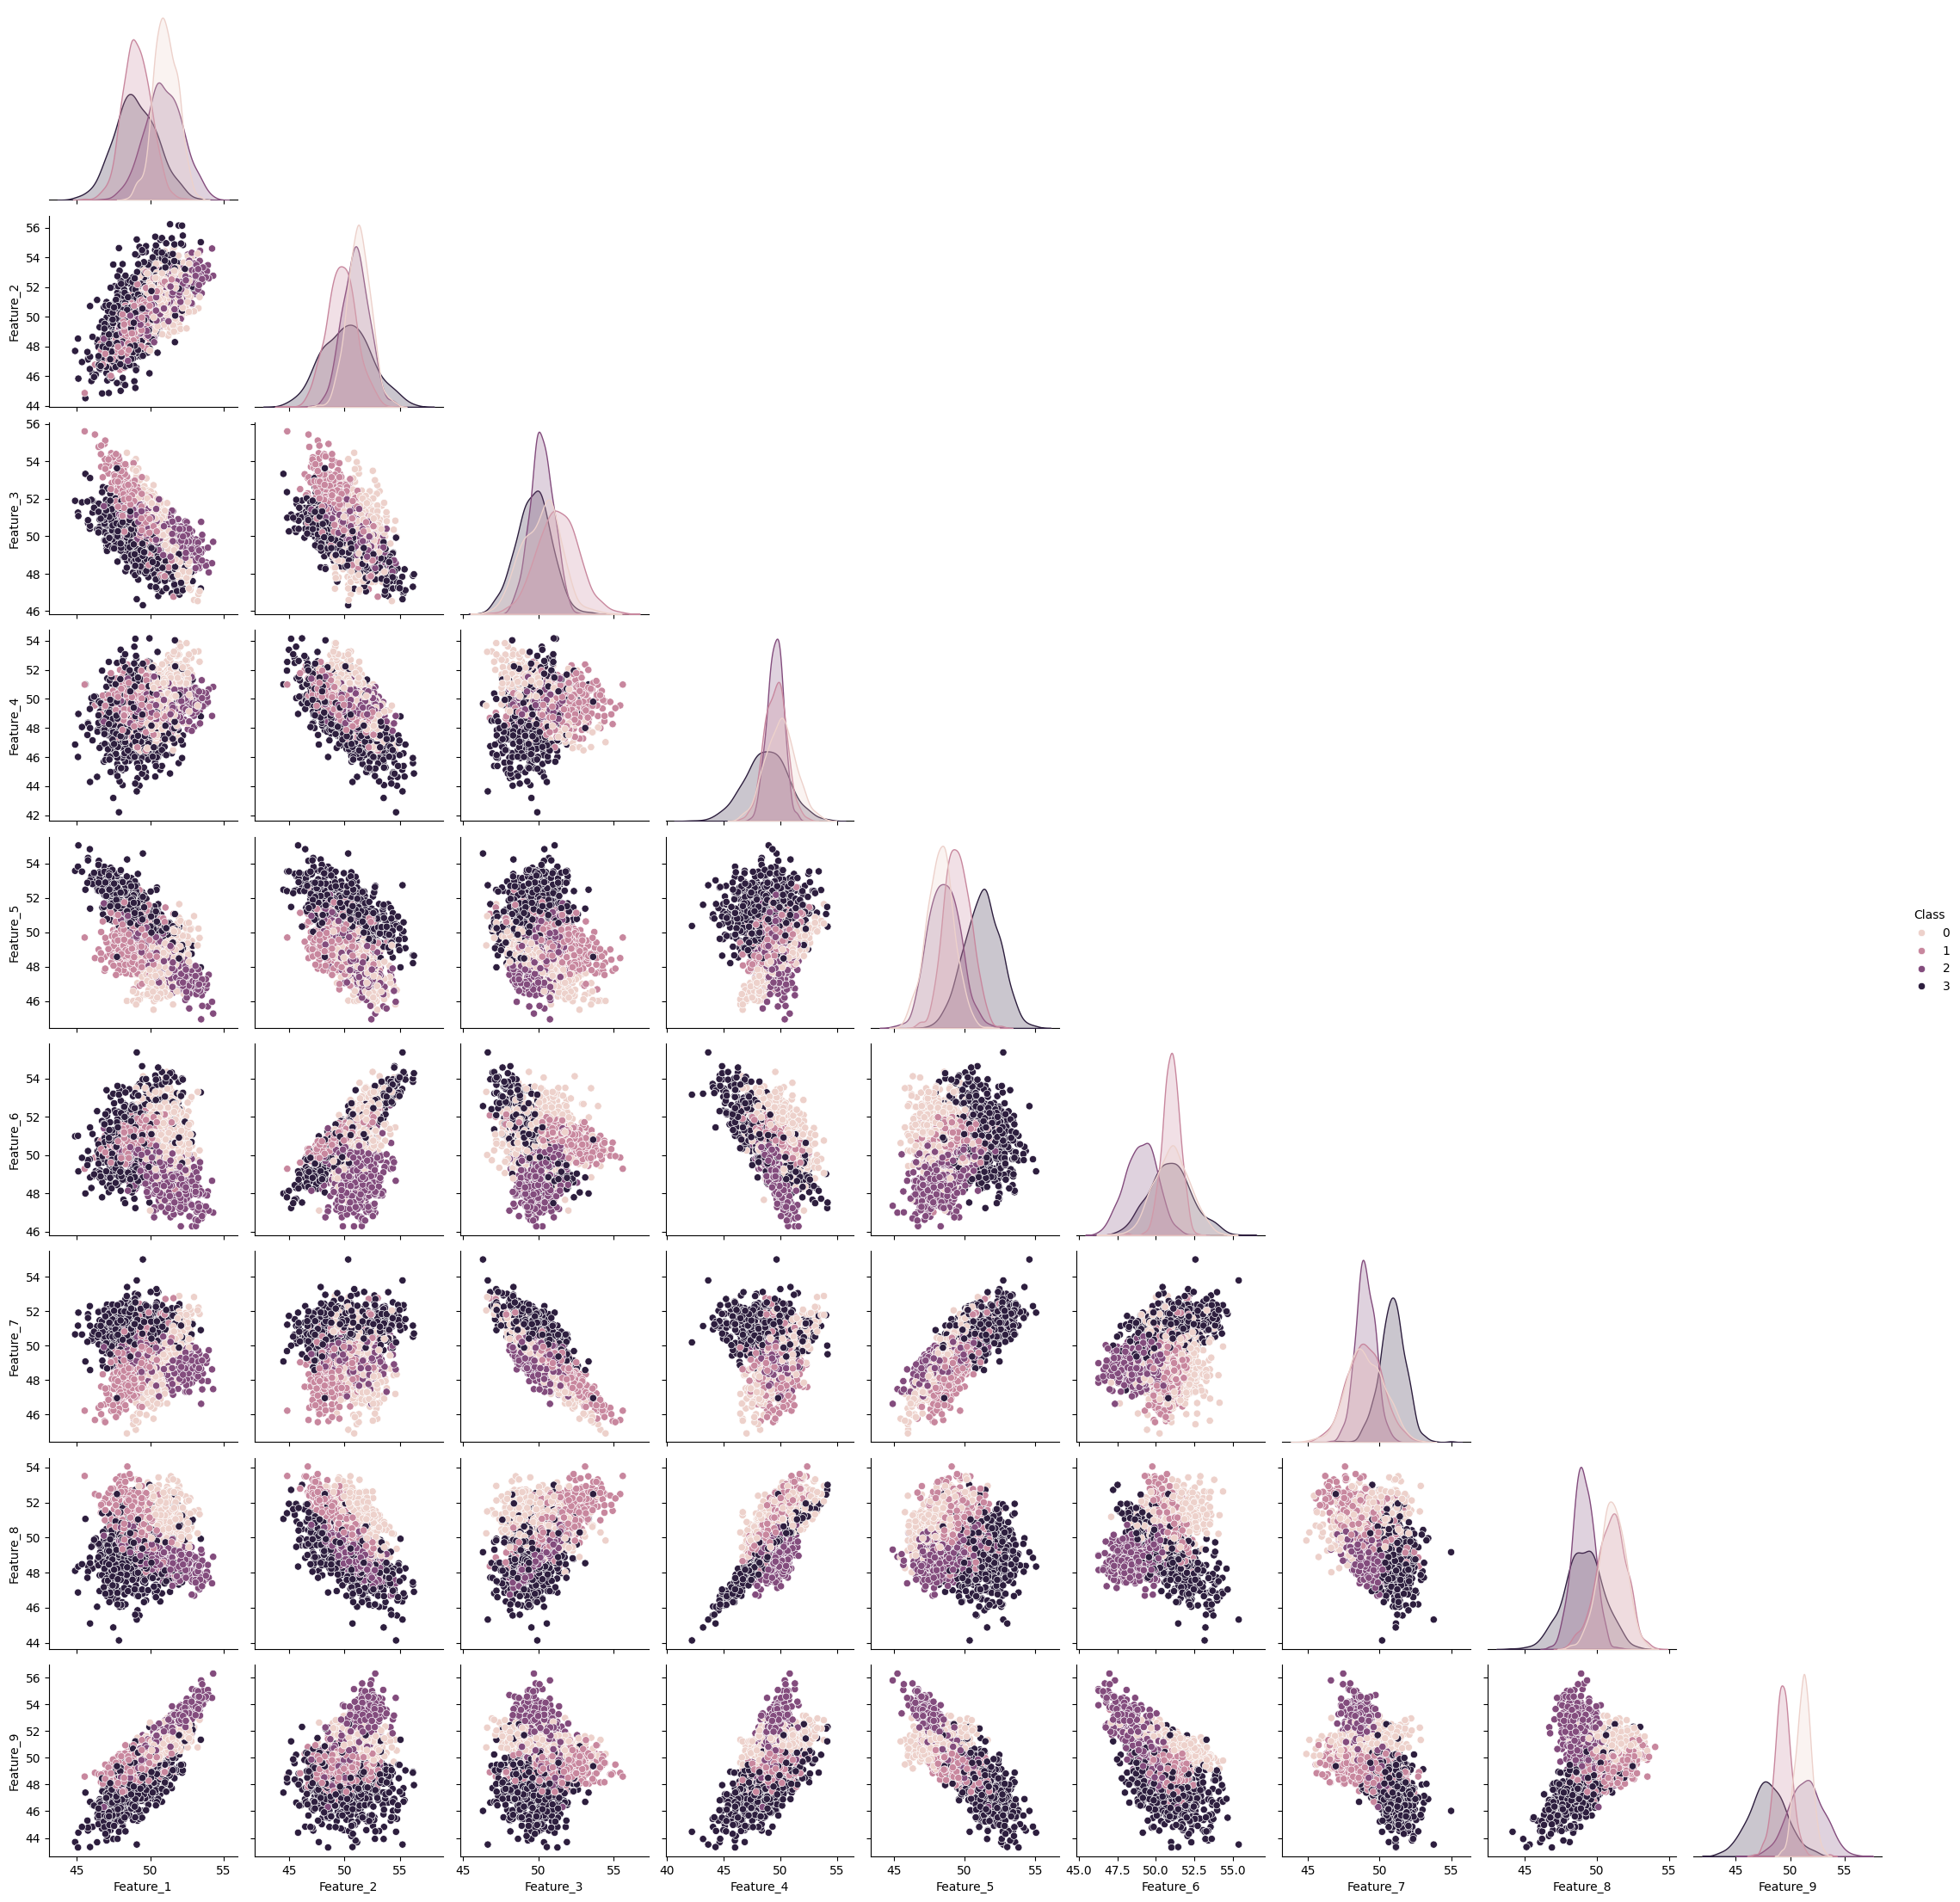

In [69]:
n_classes = 4
n_features = 9
X2, Y2 = make_classification(n_features=n_features, n_redundant=5, n_informative=4, n_classes=n_classes, n_clusters_per_class=1, shift=50, n_samples=2500, class_sep=1.)
# print(Y2)
# checking = [0 for i in range(4)]
# for i in range(Y2.shape[0]):
#     checking[Y2[i]] += 1
# print(checking)
dat2 = pd.DataFrame(X2, columns = [[str(i) for i in range(n_features)]])
res2 = pd.DataFrame(Y2, columns = ['type'])
dat2_full = dat2.join(res2)
# for i in dat2_full.columns:
#     for j in dat2_full.columns:
#         if ( i != 'type' and j != 'type' and i < j):
#             g = sns.FacetGrid(dat2_full, hue = 'type',  legend_out=True)
#             g.map(sns.regplot, i, j, fit_reg=True, x_jitter=.1)

df = pd.DataFrame(X2, columns=[f'Feature_{i+1}' for i in range(X2.shape[1])])
df['Class'] = Y2
sns.pairplot(df, hue='Class', diag_kind='kde', corner=True)

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X2, Y2, test_size = .3)
check_acc(X_train, X_test, y_train, y_test)

[MNB] Percentage of mislabeled points out of a total 750 points : 0.153333
[CNB] Percentage of mislabeled points out of a total 750 points : 0.176000
[EM] Percentage of mislabeled points out of a total 750 points : 0.176000


In [97]:
from statistics import mean
import math as m

def stdev(numbers):
	avg = mean(numbers)
	variance = sum([(x - avg) ** 2 for x in numbers]) / float(len(numbers) - 1)
	return m.sqrt(variance)

def prob_of(x, mean, stdev):
	exponent = m.exp(-((x - mean) ** 2 / (2 * stdev ** 2 )))
	return (1 / (m.sqrt(2 * m.pi) * stdev)) * exponent

# asd = [1, 2, 3, 6]
# for i in range(4):
# 	print(prob_of(asd[i], mean(asd), stdev(asd)))

def data_stat_info(data):
	stats = [(mean(column), stdev(column), len(column)) for column in zip(*data)]
	return stats

def split_classes(data, classes, n_classes):
	if (len(data) != len(classes)):
		print('len(data) != len(classes)')
		return
	splitted = [[] for _ in range(n_classes)]
	for j in range(len(data)):
		splitted[classes[j]].append(data[j])
	return splitted

def data_stats(splitted):
	data_class_stats = []
	for i in range(len(splitted)):
		stats = data_stat_info(splitted[i])
		data_class_stats.append(stats)
		# print(stats)
	return data_class_stats

def class_prob_of(stats, row):
	total_rows = sum([stats[i][0][2] for i in range(len(stats))])
	probs = dict()
	for i in range(len(stats)):
		probs[i] = stats[i][0][2] / float(total_rows)
		for j in range(len(stats[i])):
			mean, stdev, count = stats[i][j]
			probs[i] *= prob_of(row[j], mean, stdev)
	return probs

def find_best_of(row_prob):
	idx = 0
	cur_max = 0
	for i in range(len(row_prob)):
		if cur_max < row_prob[i]:
			cur_max = row_prob[i]
			idx = i
	return idx

def test_results(row_prob, klass):
	pred = find_best_of(row_prob)
	if pred == klass:
		return 1
	else:
		return 0

def fit_pridect_take_score(X_train, X_test, y_train, y_test, n_classes):
	splitted = split_classes(X_train, y_train, n_classes)
	# print(splitted)
	data_class_stats = data_stats(splitted)
	# print(data_class_stats)
	scores = []
	for i in range(len(X_test)):
		row_prob = class_prob_of(data_class_stats, X_test[i])
		scores.append(test_results(row_prob, y_test[i]))
	return scores

scores = fit_pridect_take_score(X_train, X_test, y_train, y_test, n_classes)
print("[Handwritten NB] Percentage of mislabeled points out of a total %d points : %f" % (X_test.shape[0], scores.count(0) / X_test.shape[0]))

[Handwritten NB] Percentage of mislabeled points out of a total 750 points : 0.141333
